데이터 전처리 완료! 데이터 개수: 19671
주요 변수 요약 통계량 (Summary)


,표본수(count),평균(mean),표준편차(std),최소(min),1사분위(25%),중앙값(50%),3사분위(75%),최대(max),범위(range)
총 운항,19671.0,67.36,54.30,0.0,34.00,60.0,63.00,434.0,434.0
총 공급,19671.0,15315.52,13411.03,13.0,6615.00,11362.0,18910.00,93463.0,93450.0
총 여객,19671.0,11745.98,10837.81,0.0,4705.50,9108.0,14211.00,80744.0,80744.0
L/F,19671.0,0.76,0.16,0.0,0.67,0.8,0.88,1.0,1.0


--------------------------------------------------------------------------------


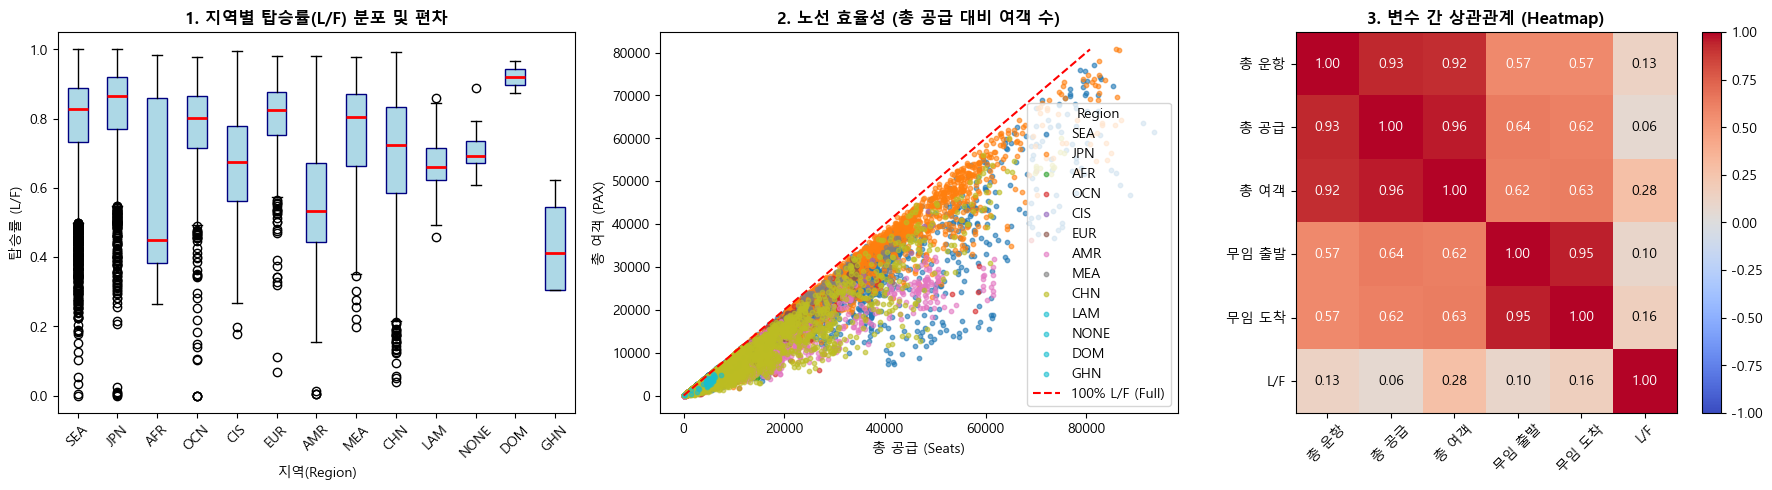

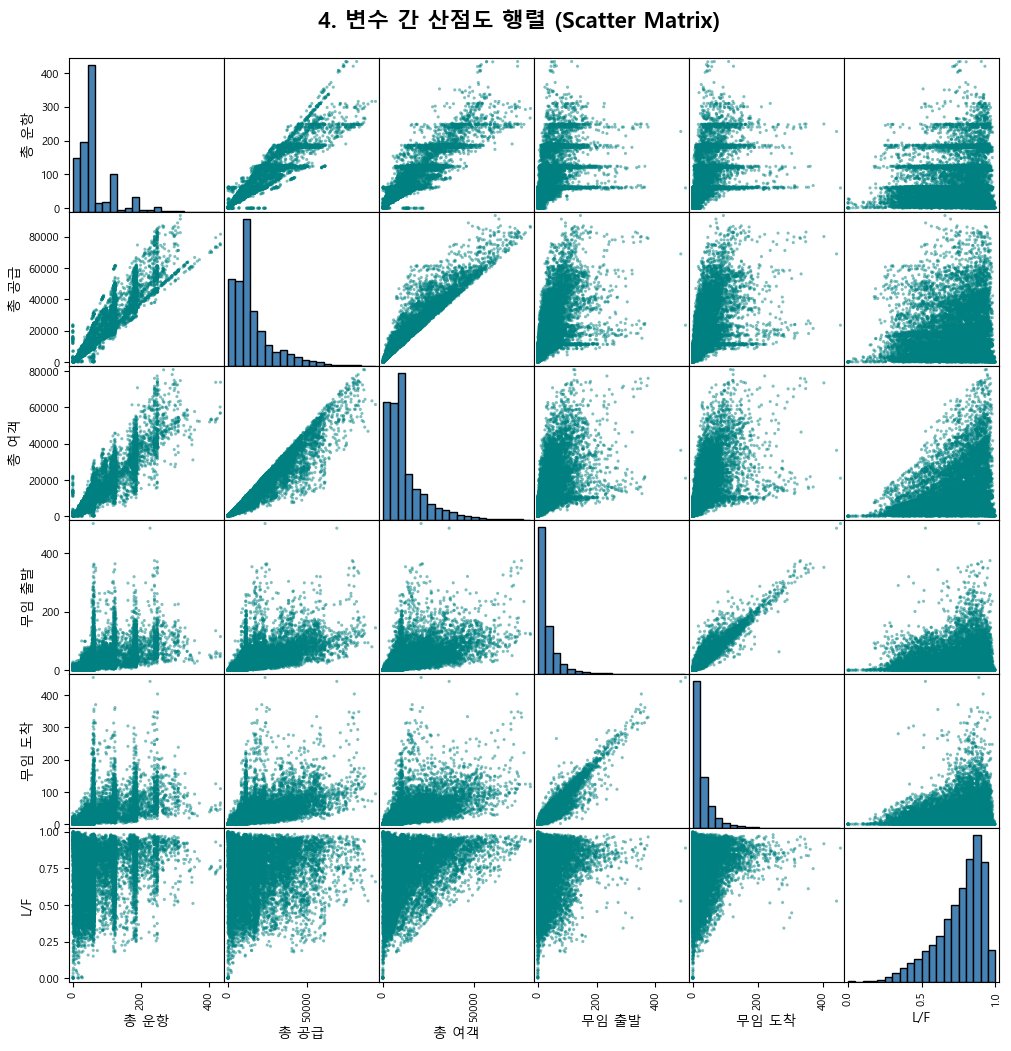

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 깨짐 방지
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 

## 1. 데이터 import
df = pd.read_csv('../data/항공통계 자료_int.csv')

# 화물기 제외 처리
df = df[df['여객/화물'] == '여객기'].copy()

# 백단위 구분 콤마 제거
cols_to_clean = ['여객 출발', '여객 도착', '공급 출발', '공급 도착', '총 여객', '총 공급', '총 운항']
for col in cols_to_clean:
    if df[col].dtype == object:
        df[col] = df[col].astype(str).str.replace(',', '').astype(float)
    else:
        df[col] = df[col].astype(float)

# 0 DIV 오류 방지를 위해 결측치 및 이상치(0) 제거
df = df[(df['총 공급'].notna()) & (df['총 공급'] > 0)]

# 탑승률(Load Factor) 계산 및 1.0 이상의 이상치 캡핑
df['L/F'] = df['총 여객'] / df['총 공급']
df['L/F'] = df['L/F'].clip(upper=1.0)

# 시계열 분석을 위한 날짜 변환 (추후 모델링 시 활용)
df['Date'] = pd.to_datetime(df['년월'], format='%b-%y')

# 상관관계 분석용 변수 (히트맵 및 산점도 행렬용)
corr_cols = ['총 운항', '총 공급', '총 여객', '무임 출발', '무임 도착', 'L/F']

# 무임승객 콤마 제거 전처리
for col in ['무임 출발', '무임 도착']:
    if df[col].dtype == object:
        df[col] = df[col].astype(str).str.replace(',', '').astype(float)

print("데이터 전처리 완료! 데이터 개수:", len(df))

print("주요 변수 요약 통계량 (Summary)")
# 기초 통계량 계산 후 보기 편하게 행/열 전환(T)
summary_df = df[['총 운항', '총 공급', '총 여객', 'L/F']].describe().T
# Range(범위 = 최대값 - 최소값) 계산 추가
summary_df['range'] = summary_df['max'] - summary_df['min']
# 출력할 컬럼 순서 정리 및 이름 변경
summary_df = summary_df[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'range']]
summary_df.columns = ['표본수(count)', '평균(mean)', '표준편차(std)', '최소(min)', '1사분위(25%)', '중앙값(50%)', '3사분위(75%)', '최대(max)', '범위(range)']

# 주피터 노트북 환경에 맞게 표 형태로 깔끔하게 출력
display(summary_df.round(2))
print("-" * 80)

## 2. EDA
fig = plt.figure(figsize=(18, 5))

# 1. 지역별 탑승률 분포 (Boxplot)
ax1 = fig.add_subplot(1, 3, 1)
regions = df['REGION'].dropna().unique()
box_data = [df[df['REGION'] == r]['L/F'].dropna() for r in regions]

# labels ver warning 해결
ax1.boxplot(box_data, tick_labels=regions, patch_artist=True, 
            boxprops=dict(facecolor='lightblue', color='navy'),
            medianprops=dict(color='red', linewidth=2))
ax1.set_title('1. 지역별 탑승률(L/F) 분포 및 편차', fontweight='bold')
ax1.set_xlabel('지역(Region)')
ax1.set_ylabel('탑승률 (L/F)')
ax1.tick_params(axis='x', rotation=45)

# 2. 노선 효율성 (Scatter - 공급 vs 여객)
ax2 = fig.add_subplot(1, 3, 2)
colors = plt.colormaps.get_cmap('tab10')

for i, r in enumerate(regions):
    subset = df[df['REGION'] == r]
    # [수정포인트 2] s=10 을 추가하여 점 크기를 작게 조절
    ax2.scatter(subset['총 공급'], subset['총 여객'], label=r, alpha=0.6, color=colors(i), s=10)
    
max_val = min(df['총 공급'].max(), df['총 여객'].max())
ax2.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='100% L/F (Full)')
ax2.set_title('2. 노선 효율성 (총 공급 대비 여객 수)', fontweight='bold')
ax2.set_xlabel('총 공급 (Seats)')
ax2.set_ylabel('총 여객 (PAX)')
ax2.legend(title='Region')

# 3. 변수 간 상관관계 (Heatmap)
ax3 = fig.add_subplot(1, 3, 3)
corr_matrix = df[corr_cols].corr()
cax = ax3.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax, ax=ax3)

ax3.set_xticks(range(len(corr_cols)))
ax3.set_yticks(range(len(corr_cols)))
ax3.set_xticklabels(corr_cols, rotation=45)
ax3.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        text_color = "white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black"
        ax3.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", color=text_color)

ax3.set_title('3. 변수 간 상관관계 (Heatmap)', fontweight='bold')

plt.tight_layout()
plt.show()

# 3. 산점도 행렬 (Scatter Matrix)
pd.plotting.scatter_matrix(df[corr_cols], figsize=(12, 12), marker='o', 
                           hist_kwds={'bins': 20, 'color': 'steelblue', 'edgecolor': 'black'}, 
                           s=5, alpha=0.5, color='teal')
plt.suptitle('4. 변수 간 산점도 행렬 (Scatter Matrix)', fontsize=16, fontweight='bold', y=0.92)
plt.show()

## 3. EDA 결과 및 비즈니스 인사이트

**1) 지역별 탑승률(L/F) 분포 및 이상치 분석 (Boxplot)**
* **핵심 수익 노선 (SEA, JPN):** 동남아시아(SEA)와 일본(JPN) 노선은 L/F 데이터가 상단에 밀집해 있으며 IQR이 비교적 좁게 형성되어 있습니다. 이는 해당 지역이 연중 안정적이고 균일한 고수요를 창출하는 캐시카우(Cash Cow) 역할을 하고 있음을 시사합니다.
* **노선별 편차 및 스펙트럼 (CHN, AFR):** 중국(CHN)의 경우 전체 공급 비중이 높고 취항하는 지방 공항이 다수 존재하여, 수익성이 높은 핵심 노선과 저조한 노선이 혼재되어 넓은 IQR과 다수의 이상치(Outliers)를 발생시키고 있습니다. 아프리카(AFR) 등 특수 노선은 표본 자체가 적어 L/F 편차가 크게 나타납니다.

**2) 노선 효율성 (Scatter: 총 공급 vs 총 여객)**
* **규모와 효율의 상관관계 파악:** JPN 노선의 강세가 시각적으로도 뚜렷하게 확인됩니다. 대다수의 점들이 100% L/F(붉은 점선)에 근접해 있어 공급 대비 여객 수송 효율이 극대화되어 있습니다.
* **해석상 주의점:** 공급량이 절대적으로 부족한 신규/소형 노선의 경우 소수의 여객 증감만으로도 효율성(L/F) 변동 폭이 크게 나타나므로, 본 산점도만으로 약세 노선을 단정 짓기보다는 절대적 볼륨(Volume)과 상대적 비율(Ratio)을 함께 고려해야 합니다.

**3) 변수 간 상관관계 및 도메인 특성 (Heatmap & Scatter Matrix)**
* **다중공선성(Multicollinearity) 확인:** 총 운항, 총 공급, 총 여객 세 가지 볼륨 지표는 서로 상관계수가 0.95 이상으로 매우 강한 선형 비례 관계를 갖습니다. 즉, 여객 수의 증가는 항공사의 임의적인 공급(운항) 추가에 강하게 종속되어 있습니다.
* **항공 스케줄링의 구조적 특성 발현:** 산점도 행렬에서 총 운항과 관련된 분포를 보면, 점들이 흩뿌려지지 않고 뚜렷한 **'선형의 줄(Band) 형태'**를 띠는 것을 확인할 수 있습니다. 이는 항공업계 특성상 '데일리 운항(주 7회, 14회 등)'과 같이 정형화된 스케줄 단위로 기재가 투입되는 도메인적 특성이 데이터에 그대로 반영된 결과입니다.

**향후 모델링(Modeling)을 위한 시사점**
단순히 '총 여객 수'를 예측 타깃으로 설정할 경우, 모델은 단순히 '공급이 많은 노선이 여객도 많다'는 기계적인 볼륨 패턴만 학습할 위험(Target Leakage)이 큽니다. 따라서 규모에 의한 편향을 제거하고 순수한 수요의 강도를 예측하기 위해, 규모 변수들이 통제된 **탑승률(L/F)을 핵심 타깃(Target) 변수로 설정하거나 볼륨 변수들을 모델링 피처에서 제외하는 방식**으로 접근해야 합니다.